# Análise exploratória dos dados
A seguir, vamos fazer a parte da EDA do projeto. Específicamente da tabela `alunos_alfabetizacao` da camada Gold que foi construída no tech challenge da fase 2.

## Pergunta norteadora
Dado o contexto do aluno, da escola e do município, é possível prever se um aluno será considerado alfabetizado?

## Variável Target
Nossa variável target será a coluna `alfabetizado`, respondendo a pergunta norteadora se um aluno será considerado alfabetizado ou não.

In [57]:
# Instalação do matplotlib e seaborn para importar as bibliotecas
!pip install matplotlib seaborn
# Instalando SHAP
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\carol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\carol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# Importações
# Utilizaremos pandas para ler o arquivo de dados
import pandas as pd

# Matplotlib e Seaborn para podermos plotar os gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Para separar em treino e teste vamos utilizar train_test_split
from sklearn.model_selection import train_test_split

# Para label encoder
from sklearn.preprocessing import LabelEncoder

# Para feature Scaler (padronização das features)
from sklearn.preprocessing import StandardScaler

# Regressão logística
from sklearn.linear_model import LogisticRegression

# Decision Tree de classificação
from sklearn.tree import DecisionTreeClassifier

# Para plotar o gráfico de árvore
from sklearn.tree import plot_tree

# Random forest de classificação
from sklearn.ensemble import RandomForestClassifier

# Acurácia
from sklearn.metrics import accuracy_score

# MI - Feature selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE

from sklearn.metrics import classification_report, confusion_matrix

# SHAP
import shap

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [59]:
# Carregando os dados, que são provenientes da fase 2
df_alfabetizacao = pd.read_parquet("../data/gold/alunos_alfabetizacao.parquet")

In [60]:
df_alfabetizacao.head()

,ano,id_aluno,id_escola,id_municipio,id_municipio_nome,sigla_uf,sigla_uf_nome,serie,rede,presenca,...,icg_nivel_5,icg_nivel_6,tdi_ef_2_ano_anterior,taxa_aprovacao_ef_2_ano_anterior,taxa_reprovacao_ef_2_ano_anterior,taxa_abandono_ef_2_ano_anterior,inse_medio,quantidade_escolas_inse,alfabetizado,_gold_processed_at
0,2023,11017171,60000268,1101492,São Francisco do Guaporé,RO,Rondônia,2° ano do Ensino Fundamental,Municipal,Ausente,...,5.9,NaN,1.2,100.0,0.0,0.0,4.955714,7.0,Não,2026-09-06 21:55:14.376808
1,2023,13026795,60001172,1302603,Manaus,AM,Amazonas,2° ano do Ensino Fundamental,Municipal,Ausente,...,NaN,0.0,4.7,98.1,1.4,0.5,4.853928,527.0,Não,2026-09-06 21:55:14.376808
2,2023,15057176,60001748,1504422,Marituba,PA,Pará,2° ano do Ensino Fundamental,Municipal,Ausente,...,0.0,NaN,5.0,98.7,0.2,1.1,4.501522,46.0,Não,2026-09-06 21:55:14.376808
3,2023,15090103,60002799,1506807,Santarém,PA,Pará,2° ano do Ensino Fundamental,Municipal,Ausente,...,0.0,2.1,3.4,94.0,5.8,0.2,4.262667,195.0,Não,2026-09-06 21:55:14.376808
4,2023,15037662,60002957,1502400,Castanhal,PA,Pará,2° ano do Ensino Fundamental,Municipal,Ausente,...,NaN,NaN,10.3,91.8,7.6,0.6,4.454194,62.0,Não,2026-09-06 21:55:14.376808


In [61]:
df_alfabetizacao.describe().round(2)

,ano,id_aluno,id_escola,id_municipio,peso_aluno,taxa_alfabetizacao_municipio,media_portugues_municipio,taxa_alfabetizacao_uf,media_portugues_uf,proficiencia,...,icg_nivel_4,icg_nivel_5,icg_nivel_6,tdi_ef_2_ano_anterior,taxa_aprovacao_ef_2_ano_anterior,taxa_reprovacao_ef_2_ano_anterior,taxa_abandono_ef_2_ano_anterior,inse_medio,quantidade_escolas_inse,_gold_processed_at
count,1747439.0,1747439.0,1747439.0,1747439.0,1502809.00,1746385.00,1746385.00,1747439.00,1747439.00,1502809.00,...,1746760.00,605870.00,624743.00,1747399.00,1747399.00,1747399.00,1747399.00,1746238.00,1746238.00,1747439
mean,2023.0,31649371.14,60021081.99,3169498.22,1.16,57.43,746.31,57.45,746.32,747.56,...,2.01,0.95,6.12,4.74,97.41,2.21,0.38,4.83,112.89,2026-09-06 21:55:14.376809
min,2023.0,11000001.0,60000001.0,1100015.0,0.10,2.12,673.30,30.57,712.56,578.46,...,0.00,0.00,0.00,0.00,68.40,0.00,0.00,3.50,1.00,2026-09-06 21:55:14.376808
25%,2023.0,24002869.5,60009751.0,2402006.0,1.00,46.72,734.09,49.20,736.07,718.84,...,0.70,0.00,0.00,1.90,97.10,0.00,0.00,4.50,12.00,2026-09-06 21:55:14.376808
50%,2023.0,31089634.0,60020359.0,3131307.0,1.09,57.00,743.96,58.74,747.42,752.15,...,1.60,0.00,0.50,3.80,98.90,0.50,0.20,4.86,32.00,2026-09-06 21:55:14.376808
75%,2023.0,41105907.5,60034237.0,4119509.0,1.24,67.75,755.55,63.65,752.13,778.73,...,2.70,0.30,2.10,6.20,99.80,2.30,0.50,5.19,93.00,2026-09-06 21:55:14.376808
max,2023.0,52083816.0,60042811.0,5222302.0,142.55,100.00,868.46,84.49,795.73,904.38,...,50.00,100.00,100.00,42.60,100.00,31.60,7.10,5.98,1213.00,2026-09-06 21:55:14.376808
std,0.0,10834071.9,13132.93,1082193.25,0.48,16.39,20.87,12.03,15.84,48.23,...,1.86,4.57,17.53,3.93,3.93,3.86,0.63,0.44,227.89,NaN


In [62]:
df_alfabetizacao.dtypes

ano                                           Int64
id_aluno                                      Int64
id_escola                                     Int64
id_municipio                                  Int64
id_municipio_nome                    string[python]
sigla_uf                                     object
sigla_uf_nome                        string[python]
serie                                string[python]
rede                                 string[python]
presenca                             string[python]
preenchimento_caderno                string[python]
peso_aluno                                  float64
taxa_alfabetizacao_municipio                float64
media_portugues_municipio                   float64
taxa_alfabetizacao_uf                       float64
media_portugues_uf                          float64
proficiencia                                float64
populacao                                     Int64
pib                                         float64
pib_per_capi

In [63]:
df_alfabetizacao.isnull().sum()

ano                                        0
id_aluno                                   0
id_escola                                  0
id_municipio                               0
id_municipio_nome                          0
sigla_uf                                   0
sigla_uf_nome                              0
serie                                      0
rede                                       0
presenca                                   0
preenchimento_caderno                      0
peso_aluno                            244630
taxa_alfabetizacao_municipio            1054
media_portugues_municipio               1054
taxa_alfabetizacao_uf                      0
media_portugues_uf                         0
proficiencia                          244630
populacao                                  0
pib                                        0
pib_per_capita                             0
meta_alfabetizacao_2024_municipio     215041
meta_alfabetizacao_2024_uf                 0
meta_alfab

In [64]:
# Exibindo total de alunos alfabetizados, separados por sim/não
print(f"Quantidade da coluna {df_alfabetizacao["alfabetizado"].value_counts()}")
print(f"Proporção da coluna {(df_alfabetizacao["alfabetizado"].value_counts(normalize=True) * 100).round(2)}")

Quantidade da coluna alfabetizado
Sim    877427
Não    870012
Name: count, dtype: Int64
Proporção da coluna alfabetizado
Sim    50.21
Não    49.79
Name: proportion, dtype: Float64


In [65]:
for colunas_categoricas in ["id_municipio_nome","sigla_uf","sigla_uf_nome", "alfabetizado", "serie", "rede", "presenca", "preenchimento_caderno"]:
    print(f"Coluna: {df_alfabetizacao[colunas_categoricas].value_counts()}")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

Coluna: id_municipio_nome
Rio de Janeiro           54533
Manaus                   33096
Belo Horizonte           21086
Fortaleza                20171
Salvador                 16101
                         ...  
Tupirama                    11
Santo Expedito do Sul       10
Rio dos Índios              10
Paiva                       10
Conceição de Ipanema        10
Name: count, Length: 4652, dtype: Int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Coluna: sigla_uf
MG    210107
RJ    159997
PR    138532
BA    137724
RS    121148
PA    104972
SC    102621
CE    100349
PE     88271
GO     83741
MA     74958
AM     63055
MT     54526
ES     50482
MS     42199
PB     38215
AL     35503
PI     35415
RN     31748
RO     22834
TO     20059
SE     18634
AP     12349
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Coluna: sigla_uf_nome
Minas Gerais           210107
Rio de Janeiro         159997
Paraná                 138532
Bahia                  137724
Rio Grande do Sul      121148
Pará                 

In [66]:
todas_ufs = {"AC","AL","AP","AM","BA","CE","DF","ES","GO","MA","MT","MS","MG","PA","PB","PR","PE","PI","RJ","RN","RS","RO","RR","SC","SP","SE","TO"}
ufs_presentes = set(df_alfabetizacao["sigla_uf"].dropna().unique())

print("UFs faltando:", todas_ufs - ufs_presentes)

UFs faltando: {'DF', 'AC', 'RR', 'SP'}


**Limitação**: faltam 4 UFs inteiras na base: SP, AC, RR e DF. </br>
SP é a mais grave, por ser o estado mais populoso do Brasil, qualquer modelo treinado aqui não pode ser generalizado para esse estado.

In [67]:
# Identificando outlier presente na coluna "peso_aluno", confirmando que é acima de 0.999
print(df_alfabetizacao["peso_aluno"].quantile([0.95, 0.99, 0.999, 1.0]))

0.950      1.603785
0.990      2.158272
0.999      4.579347
1.000    142.545400
Name: peso_aluno, dtype: float64


In [68]:
# Descobrindo de quais UFs estão vindo os outliers
df_alfabetizacao.nlargest(10, "peso_aluno")[["id_aluno","sigla_uf","id_municipio_nome","rede","peso_aluno"]]

,id_aluno,sigla_uf,id_municipio_nome,rede,peso_aluno
1320835,33043600,RJ,Macaé,Municipal,142.545400
195074,33113247,RJ,Rio de Janeiro,Municipal,116.004200
1072457,42061530,SC,Joinville,Municipal,113.061711
655487,33060043,RJ,Nova Iguaçu,Municipal,108.144928
1693199,33028603,RJ,Duque de Caxias,Municipal,105.356600
973316,33047350,RJ,Magé,Municipal,95.448040
670152,33055617,RJ,Niterói,Municipal,79.724580
371321,29089205,BA,Santo Antônio de Jesus,Municipal,72.564544
1656260,26064181,PE,Serra Talhada,Municipal,71.484241
1460217,33134793,RJ,São Fidélis,Municipal,67.698190


In [69]:
# Todos os alunos que tem presença sim/não são alfabetizados?
print("Comparativo alfabetizado vs presença")
print(pd.crosstab(df_alfabetizacao["presenca"], df_alfabetizacao["alfabetizado"]))

Comparativo alfabetizado vs presença
alfabetizado     Não     Sim
presenca                    
Ausente       244381       0
Presente      625631  877427


## Decisão de base
Após comparar quantos dos alunos tinham a coluna preenchida com alfabetizado sim/não observamos que todos que estavam "Ausentes" foram classificados como "Não", essa é uma **regra de atribuição do sistema de avaliação**. Sem nota registrada quer dizer que não passa no corte, não uma medição real da alfabetização desses alunos.</br></br>
Decidimos que não vamos incluir os alunos que foram classificados como "Ausentes" pois, na nossa base, não temos agregações que ajudem a descobrir a causa real do porquê os alunos não puderam realizar a prova.

In [70]:
df_alfabetizacao_presentes = df_alfabetizacao[df_alfabetizacao["presenca"] == "Presente"].copy()
qtde_anterior = len(df_alfabetizacao)
qtde_atual = len(df_alfabetizacao_presentes)

print(f"Quantidade de alunos antes do filtro de presentes: {qtde_anterior}")
print(f"Quantidade de alunos após: {qtde_atual}")
print(f"Removidos {qtde_anterior - qtde_atual} ({(qtde_anterior-qtde_atual)/qtde_anterior*100:.2f}%)")

Quantidade de alunos antes do filtro de presentes: 1747439
Quantidade de alunos após: 1503058
Removidos 244381 (13.99%)


In [71]:
df_alfabetizacao_presentes.isnull().sum()

ano                                       0
id_aluno                                  0
id_escola                                 0
id_municipio                              0
id_municipio_nome                         0
sigla_uf                                  0
sigla_uf_nome                             0
serie                                     0
rede                                      0
presenca                                  0
preenchimento_caderno                     0
peso_aluno                              249
taxa_alfabetizacao_municipio            163
media_portugues_municipio               163
taxa_alfabetizacao_uf                     0
media_portugues_uf                        0
proficiencia                            249
populacao                                 0
pib                                       0
pib_per_capita                            0
meta_alfabetizacao_2024_municipio    174204
meta_alfabetizacao_2024_uf                0
meta_alfabetizacao_2024_brasil  

Podemos observar que tanto a quantidade de nulos da coluna peso_aluno quanto da proficiência diminuíram exatamente na mesma quantidade de alunos que identificamos como "Ausentes" (de 244.630 para 249) confirmando que o filtro de presença resolveu, por consequência, o problema de nulo nessas duas colunas. Os 249 casos residuais são alunos marcados como "Presente" que, mesmo assim, não completaram a prova (prova em branco/invalidada).

In [72]:
# Check de proficiencia dos casos residuais
print(pd.crosstab(df_alfabetizacao_presentes["preenchimento_caderno"], df_alfabetizacao_presentes["proficiencia"].isna()))

proficiencia             False  True 
preenchimento_caderno                
Prova não preenchida         0    249
Prova preenchida       1502809      0


### DATA LEAKAGE
Identificamos que as colunas a seguir contém dados que já dariam a resposta ao modelo.

- proficiencia </br>
    A target é calculada a partir dessa variável (que vimos na fase 2 sobre a nota de corte: 743)
- taxa_alfabetizacao_municipio </br>
    É a porcentagem de alunos alfabetizados por município, o calculo inclui o aluno da linha
- taxa_alfabetizacao_uf </br>
    Mesmo mecanismo da coluna acima, só que diluído por UF (grupo maior → vazamento mais fraco)
- media_portugues_municipio </br>
    É a média de proficiência do município. Mesmo problema de taxa_alfabetizacao_municipio, incluindo a nota do próprio aluno no cálculo
- media_portugues_uf </br>
    Mesmo mecanismo da coluna "media_portugues_municipio", diluído por UF

In [73]:
# Identificando leakage da coluna proficiencia
df_leakage = df_alfabetizacao_presentes.dropna(subset=["proficiencia"]).copy()
df_leakage["regra_aplicada"] = (df_leakage["proficiencia"] >= 743).map({True: "Sim", False: "Não"})
regra = (df_leakage["regra_aplicada"] == df_leakage["alfabetizado"]).mean() * 100
print(f"Porcentagem de vezes que 'proficiencia >= 743' bate com o alfabetizado real: {regra:.2f}%")

Porcentagem de vezes que 'proficiencia >= 743' bate com o alfabetizado real: 100.00%


In [74]:
colunas_leakage = [
    "proficiencia",
    "taxa_alfabetizacao_municipio",
    "taxa_alfabetizacao_uf",
    "media_portugues_municipio",
    "media_portugues_uf",
]

df_modelagem = df_alfabetizacao_presentes.drop(columns=colunas_leakage)
print(df_modelagem.shape)

(1503058, 38)


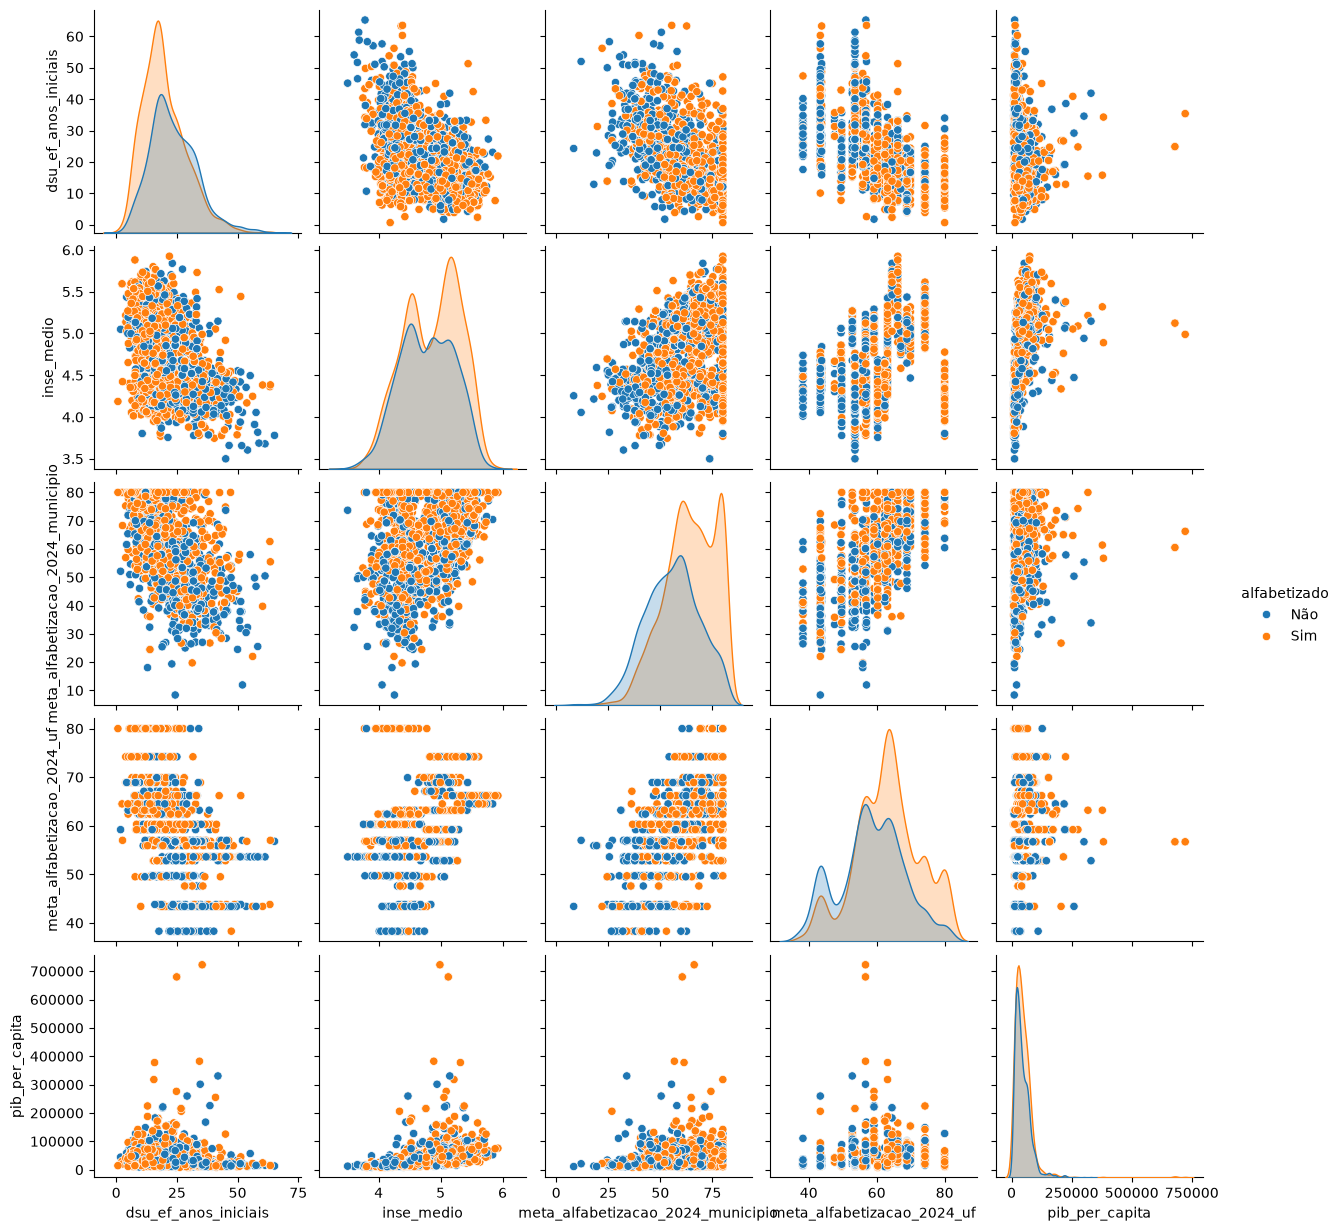

In [75]:
colunas_pairplot = [
    "dsu_ef_anos_iniciais", "inse_medio", "meta_alfabetizacao_2024_municipio",
    "meta_alfabetizacao_2024_uf", "pib_per_capita", "alfabetizado"
]

amostra = df_modelagem[colunas_pairplot].sample(3000, random_state=42)
sns.pairplot(amostra, hue="alfabetizado")

## Correlação

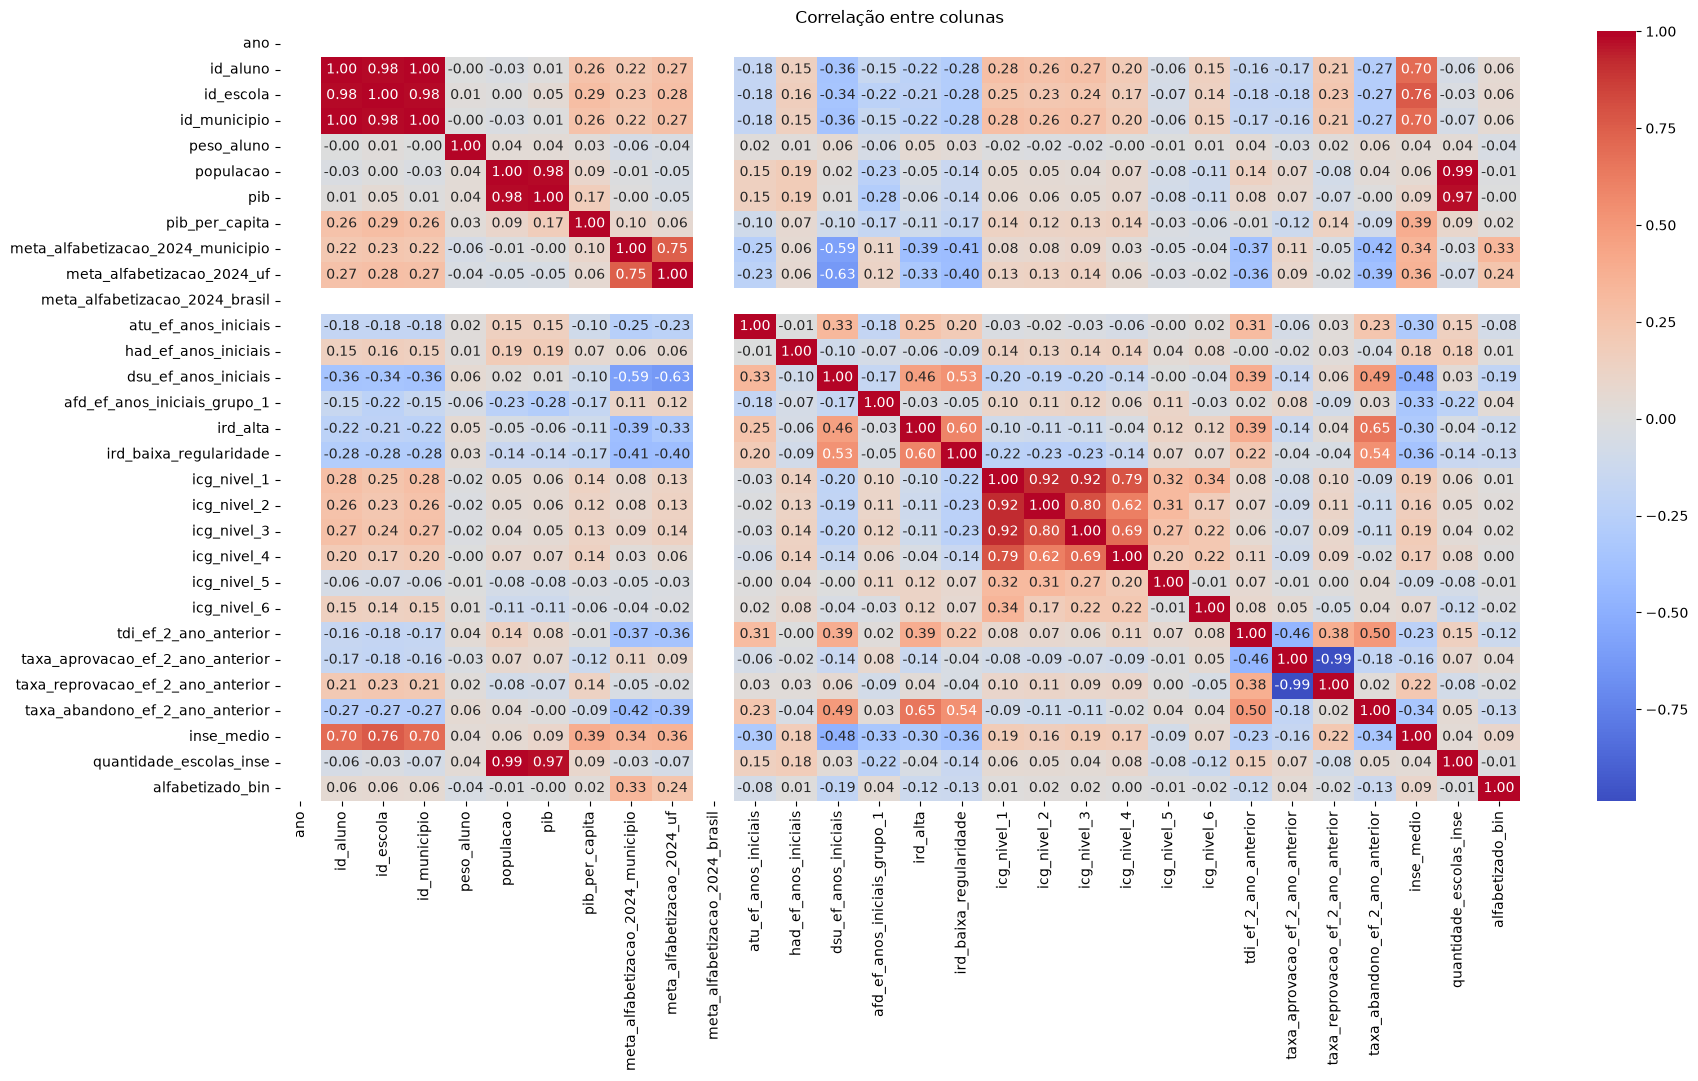

In [76]:
df_modelagem["alfabetizado_bin"] = (df_modelagem["alfabetizado"] == "Sim").astype(int)

correlacao = df_modelagem.corr(numeric_only=True)

plt.figure(figsize=(20,10))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre colunas")
plt.show()

Vamos remover os IDs que não fazem parte da análise na correlação

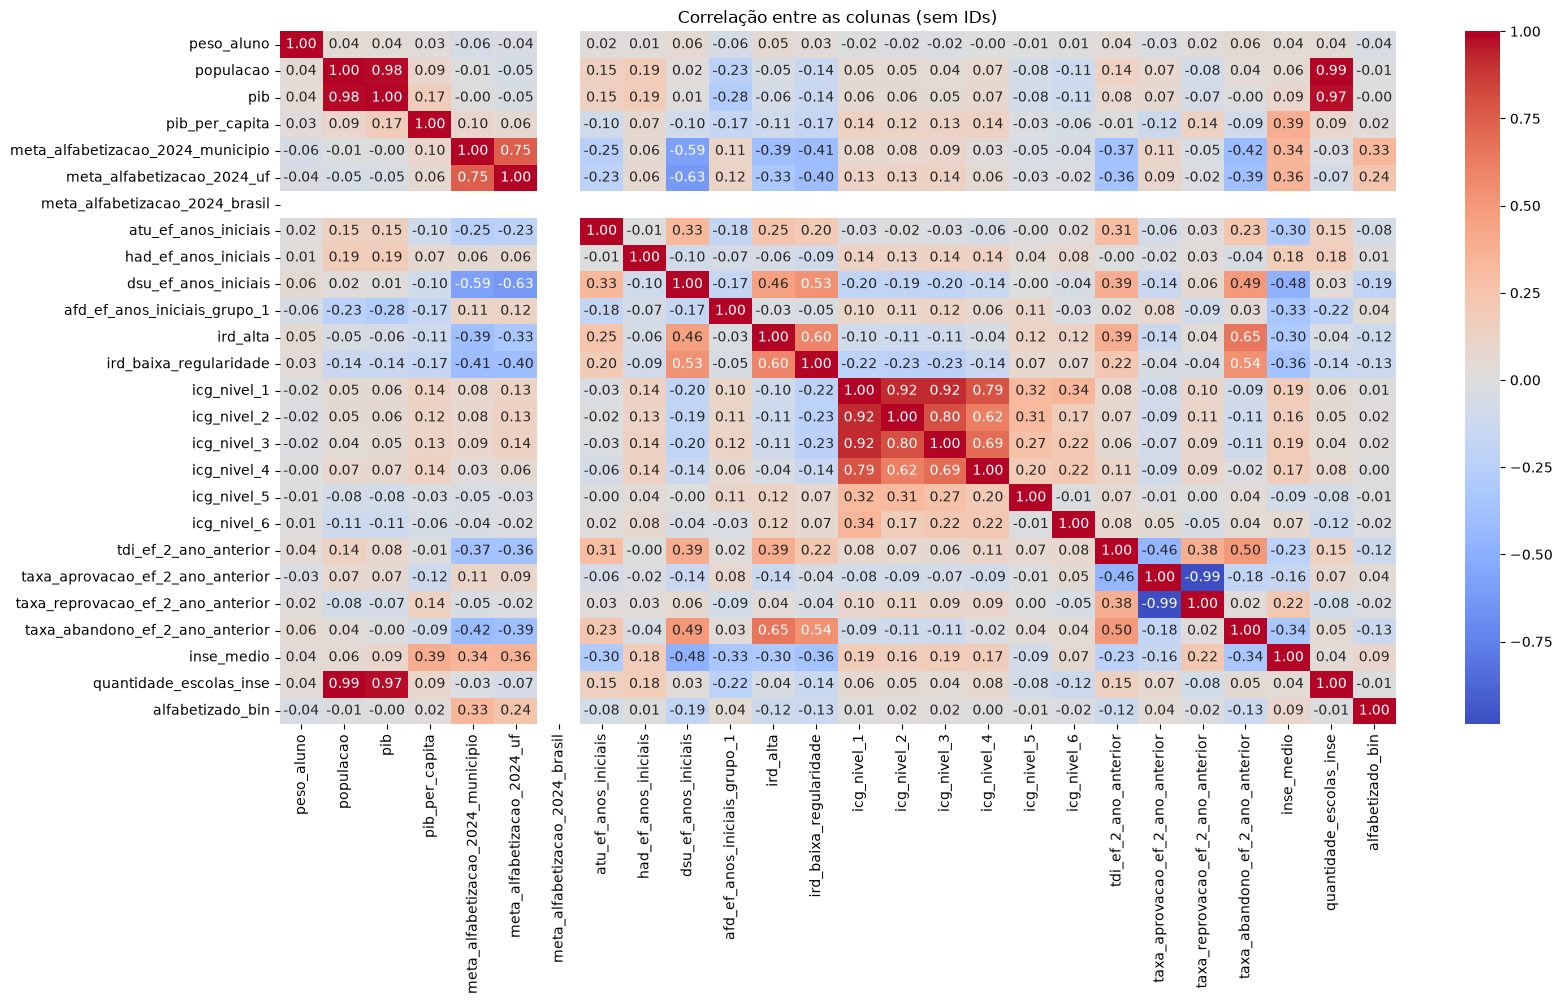

In [77]:
colunas_remover_correlacao = ["ano", "id_aluno", "id_escola", "id_municipio"]

correlacao_limpa = df_modelagem.drop(columns=colunas_remover_correlacao).corr(numeric_only=True)

plt.figure(figsize=(18,9))
sns.heatmap(correlacao_limpa, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre as colunas (sem IDs)")
plt.show()

### Multicolinearidade 1: população / pib / quantidade_escolas_inse

`população`, `pib` e `quantidade_escolas_inse` estão medindo "tamanho do município" de formas diferentes.

- `pib` (bruto) é descartado por ser redundante com `pib_per_capita`, que já usamos e que não sofre desse mesmo problema (correlaciona só 0,09-0,19 com esse cluster, porque mede riqueza por pessoa, não tamanho).
- `quantidade_escolas_inse` Correlaciona bem com população porque cidade grande normalmente tem mais escolas participando do SAEB, não porque a coluna "signifique" tamanho de cidade.

Vamos manter: `populacao` e `pib_per_capita`.

In [78]:
colunas_multico = ["pib", "quantidade_escolas_inse"]
df_modelagem = df_modelagem.drop(columns=colunas_multico)
print(df_modelagem.shape)

(1503058, 37)


### Multicolinearidade 2: taxa_aprovacao / taxa_reprovacao_ef_2_ano_anterior

`taxa_aprovacao_ef_2_ano_anterior` e `taxa_reprovacao_ef_2_ano_anterior` correlacionam -0,99 entre si, é redundância (aprovação + reprovação + abandono ≈ 100%). Mantemos `taxa_aprovacao_ef_2_ano_anterior` (correlação mais forte com a target: 0,051 vs. -0,030 da reprovação) e descartamos `taxa_reprovacao_ef_2_ano_anterior`. `taxa_abandono_ef_2_ano_anterior` não faz parte dessa redundância, é mantida por ter a correlação mais forte entre as três (-0,130).

In [79]:
colunas_multico_2 = ["taxa_reprovacao_ef_2_ano_anterior"]
df_modelagem = df_modelagem.drop(columns=colunas_multico_2)
print(df_modelagem.shape)

(1503058, 36)


### Multicolinearidade 3: icg_nivel_1 a icg_nivel_6

Os 6 níveis do ICG (Complexidade de Gestão da Escola) correlacionam fortemente entre si (0,62 a 0,92), mas nenhum individualmente correlaciona com a target (todos abaixo de 0,03). 

- **Somar os níveis**: descartado, porque os valores não somam ~100% por município (não são percentual do total de escolas), então a soma não teria interpretação clara.

Decisão: descartar os 6 níveis do ICG por completo.

In [80]:
colunas_multico_3 = ["icg_nivel_1", "icg_nivel_2", "icg_nivel_3", "icg_nivel_4", "icg_nivel_5", "icg_nivel_6"]
df_modelagem = df_modelagem.drop(columns=colunas_multico_3)
print(df_modelagem.shape)

(1503058, 30)


### had_ef_anos_iniciais

HAD = Horas-Aula Diária. É a quantidade média de horas por dia que os alunos passam em aula, no município, considerando as escolas dos anos iniciais do Ensino Fundamental.

In [81]:
total_municipios = df_modelagem["id_municipio"].nunique()
municipios_sem_had = df_modelagem[df_modelagem["had_ef_anos_iniciais"].isna()]["id_municipio"].nunique()

print(f"Total de municípios: {total_municipios}")
print(f"Municípios com pelo menos 1 aluno sem had_ef_anos_iniciais: {municipios_sem_had}")

Total de municípios: 4871
Municípios com pelo menos 1 aluno sem had_ef_anos_iniciais: 1053


In [82]:
por_municipio = df_modelagem.groupby("id_municipio")["had_ef_anos_iniciais"].apply(lambda x: x.isna().mean())
print(por_municipio.value_counts(bins=[-0.01, 0.01, 0.5, 0.99, 1.0]))

(-0.011, 0.01]    3818
(0.99, 1.0]       1053
(0.01, 0.5]          0
(0.5, 0.99]          0
Name: count, dtype: int64


In [83]:
municipios = df_modelagem.drop_duplicates("id_municipio")[["id_municipio", "populacao", "had_ef_anos_iniciais"]].copy()
municipios["tem_had"] = municipios["had_ef_anos_iniciais"].notna()

print(municipios.groupby("tem_had")["populacao"].describe())

          count          mean            std     min     25%      50%  \
tem_had                                                                 
False    1053.0   5546.416904    4523.180803   924.0  2839.0   4224.0   
True     3818.0  38885.305134  152586.051943  1318.0  7431.0  14228.5   

             75%        max  
tem_had                      
False     6576.0    44800.0  
True     28913.5  6211223.0  


`had_ef_anos_iniciais` 1.053 municípios com 100% nulo, 3.818 com 100% preenchido. Sugere que municípios pequenos não atingem um critério mínimo do INEP para esse cálculo.

Levantando o dado de que a correlação com a target também é pequena, vamos remover do dataset

In [84]:
df_modelagem = df_modelagem.drop(columns=["had_ef_anos_iniciais"])
print(df_modelagem.shape)

(1503058, 29)


### peso_aluno

No heatmap, `peso_aluno` não correlaciona com quase nada, não ajuda a explicar a alfabetização

Se parece com o outlier que já investigamos (máximo 142,55, mais ou menos 31x o percentil 99,9%, concentrado no Rio de Janeiro) reforça ainda mais que essa coluna tem uma lógica própria de desenho amostral, não uma relação direta com o desempenho do aluno

Vamos descartar `peso_aluno` também

In [85]:
df_modelagem = df_modelagem.drop(columns=["peso_aluno"])
print(df_modelagem.shape)

(1503058, 28)


In [86]:
colunas_nulos = [
    "dsu_ef_anos_iniciais", "afd_ef_anos_iniciais_grupo_1", "ird_alta", "ird_baixa_regularidade",
    "tdi_ef_2_ano_anterior", "taxa_aprovacao_ef_2_ano_anterior", "taxa_abandono_ef_2_ano_anterior",
    "inse_medio",
]

antes = len(df_modelagem)
linhas_com_algum_nulo = df_modelagem[colunas_nulos].isna().any(axis=1).sum()

print(f"Total de alunos: {antes}")
print(f"Alunos com nulo em pelo menos uma das 8 colunas: {linhas_com_algum_nulo} ({linhas_com_algum_nulo/antes*100:.3f}%)")

Total de alunos: 1503058
Alunos com nulo em pelo menos uma das 8 colunas: 1684 (0.112%)


In [87]:
mask_nulo = df_modelagem[colunas_nulos].isna().any(axis=1)

print("Distribuição de sigla_uf entre os alunos que seriam removidos:")
print(df_modelagem[mask_nulo]["sigla_uf"].value_counts())
print()
print("Distribuição do alvo entre os que seriam removidos:")
print(df_modelagem[mask_nulo]["alfabetizado"].value_counts(normalize=True).round(3) * 100)

Distribuição de sigla_uf entre os alunos que seriam removidos:
sigla_uf
PR    1019
AL     368
RS     101
TO      89
PB      74
MT      33
Name: count, dtype: int64

Distribuição do alvo entre os que seriam removidos:
alfabetizado
Sim    67.0
Não    33.0
Name: proportion, dtype: Float64


Por ser uma porcentagem muito baixa de nulos, optamos por remover as linhas nulas do dataset

In [88]:
df_modelagem = df_modelagem.dropna(subset=colunas_nulos)
print(df_modelagem.shape)
print()
print("Nulos restantes:")
nulos = df_modelagem.isna().sum()
print(nulos[nulos > 0] if (nulos > 0).any() else "Zero nulo restante")

(1501374, 28)

Nulos restantes:
meta_alfabetizacao_2024_municipio    174177
dtype: int64


Podemos observar que `meta_alfabetizacao_2024_brasil` não tem nenhuma correlação, vamos remover do dataset

In [89]:
df_modelagem = df_modelagem.drop(columns=["meta_alfabetizacao_2024_brasil"])
print(df_modelagem.shape)

(1501374, 27)


100% dos alunos de rede Estadual ficam sem `meta_alfabetizacao_2024_municipio`. a meta municipal só existe pra rede Municipal. Descartar essas linhas eliminaria 10% da base inteira. Vamos preencher com a mediana e criar uma coluna indicadora, para o modelo distinguir "valor real" de "não se aplica".

In [90]:
print(pd.crosstab(df_modelagem["rede"], df_modelagem["meta_alfabetizacao_2024_municipio"].isna()))

meta_alfabetizacao_2024_municipio    False   True 
rede                                              
Estadual                                 0  131506
Municipal                          1327197   42671


In [91]:
df_modelagem["meta_alfabetizacao_2024_municipio_disponivel"] = df_modelagem["meta_alfabetizacao_2024_municipio"].notna().astype(int)

mediana_meta_municipio = df_modelagem["meta_alfabetizacao_2024_municipio"].median()
df_modelagem["meta_alfabetizacao_2024_municipio"] = df_modelagem["meta_alfabetizacao_2024_municipio"].fillna(mediana_meta_municipio)

print("Nulos restantes:", df_modelagem["meta_alfabetizacao_2024_municipio"].isna().sum())
print(df_modelagem["meta_alfabetizacao_2024_municipio_disponivel"].value_counts())

Nulos restantes: 0
meta_alfabetizacao_2024_municipio_disponivel
1    1327197
0     174177
Name: count, dtype: int64


## Feature Encoding
transformando colunas textuais em numéricas

In [92]:
# IDs
colunas_ids = ["id_aluno", "id_escola", "id_municipio", "id_municipio_nome"]

# constantes
colunas_variancia_zero = ["ano", "serie", "presenca", "_gold_processed_at"]

# duplicada (mesma informação de sigla_uf)
coluna_duplicada = ["sigla_uf_nome"]

# somente 249 casos de "prova não preenchida" contra 1.5 milhões de "preenchidas"
coluna_desbalanceada = ["preenchimento_caderno"]

df_modelagem = df_modelagem.drop(columns=colunas_ids + colunas_variancia_zero + coluna_duplicada + coluna_desbalanceada)
print(df_modelagem.shape)

(1501374, 18)


### Utilizando one-hot encoding
O problema de utilizar outros encodings no caso de UF: </br>
label: criaria uma ordem, no nosso caso de UF não temos uma ordem. SP não é maior que BH por exemplo</br>
target: poderiamos criar uma pista para o algoritmo com base na target

In [93]:
df_modelagem = pd.get_dummies(df_modelagem, columns=["rede"], drop_first=True)
print(df_modelagem.shape)
print(df_modelagem.columns.tolist())

(1501374, 18)
['sigla_uf', 'populacao', 'pib_per_capita', 'meta_alfabetizacao_2024_municipio', 'meta_alfabetizacao_2024_uf', 'atu_ef_anos_iniciais', 'dsu_ef_anos_iniciais', 'afd_ef_anos_iniciais_grupo_1', 'ird_alta', 'ird_baixa_regularidade', 'tdi_ef_2_ano_anterior', 'taxa_aprovacao_ef_2_ano_anterior', 'taxa_abandono_ef_2_ano_anterior', 'inse_medio', 'alfabetizado', 'alfabetizado_bin', 'meta_alfabetizacao_2024_municipio_disponivel', 'rede_Municipal']


In [94]:
df_modelagem = pd.get_dummies(df_modelagem, columns=["sigla_uf"], drop_first=True)
print(df_modelagem.shape)

(1501374, 39)


In [95]:
# checando as colunas finais para entrar no treino e teste
print(df_modelagem.columns.tolist())
df_modelagem.head()


['populacao', 'pib_per_capita', 'meta_alfabetizacao_2024_municipio', 'meta_alfabetizacao_2024_uf', 'atu_ef_anos_iniciais', 'dsu_ef_anos_iniciais', 'afd_ef_anos_iniciais_grupo_1', 'ird_alta', 'ird_baixa_regularidade', 'tdi_ef_2_ano_anterior', 'taxa_aprovacao_ef_2_ano_anterior', 'taxa_abandono_ef_2_ano_anterior', 'inse_medio', 'alfabetizado', 'alfabetizado_bin', 'meta_alfabetizacao_2024_municipio_disponivel', 'rede_Municipal', 'sigla_uf_AM', 'sigla_uf_AP', 'sigla_uf_BA', 'sigla_uf_CE', 'sigla_uf_ES', 'sigla_uf_GO', 'sigla_uf_MA', 'sigla_uf_MG', 'sigla_uf_MS', 'sigla_uf_MT', 'sigla_uf_PA', 'sigla_uf_PB', 'sigla_uf_PE', 'sigla_uf_PI', 'sigla_uf_PR', 'sigla_uf_RJ', 'sigla_uf_RN', 'sigla_uf_RO', 'sigla_uf_RS', 'sigla_uf_SC', 'sigla_uf_SE', 'sigla_uf_TO']


,populacao,pib_per_capita,meta_alfabetizacao_2024_municipio,meta_alfabetizacao_2024_uf,atu_ef_anos_iniciais,dsu_ef_anos_iniciais,afd_ef_anos_iniciais_grupo_1,ird_alta,ird_baixa_regularidade,tdi_ef_2_ano_anterior,...,sigla_uf_PE,sigla_uf_PI,sigla_uf_PR,sigla_uf_RJ,sigla_uf_RN,sigla_uf_RO,sigla_uf_RS,sigla_uf_SC,sigla_uf_SE,sigla_uf_TO
236,483087,20050.920435,41.51,56.7,78.9,32.6,80.0,1.0,1.8,14.6,...,False,False,False,True,False,False,False,False,False,False
237,214493,57528.907703,62.54,64.5,13.4,14.4,76.9,0.1,0.6,1.3,...,False,False,False,False,False,False,False,True,False,False
238,214493,57528.907703,62.54,64.5,13.4,14.4,76.9,0.1,0.6,1.3,...,False,False,False,False,False,False,False,True,False,False
239,1332833,78586.943751,60.94,66.2,40.7,26.1,75.8,0.4,1.3,3.0,...,False,False,False,False,False,False,True,False,False,False
240,1332833,78586.943751,60.94,66.2,40.7,26.1,75.8,0.4,1.3,3.0,...,False,False,False,False,False,False,True,False,False,False


In [96]:
# Utilizando o label encoder para target
label_encoder = LabelEncoder()
df_modelagem["alfabetizado"] = label_encoder.fit_transform(df_modelagem["alfabetizado"])

y = df_modelagem["alfabetizado"]
X = df_modelagem.drop(columns=["alfabetizado", "alfabetizado_bin"])

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (1201099, 37)
Teste: (300275, 37)


## Padronização

In [98]:
# não vamos adicionar as colunas de UF que mudamos no feature encoding
colunas_numericas = [
    "populacao", "pib_per_capita", "atu_ef_anos_iniciais", "dsu_ef_anos_iniciais",
    "afd_ef_anos_iniciais_grupo_1", "ird_alta", "ird_baixa_regularidade",
    "tdi_ef_2_ano_anterior", "taxa_aprovacao_ef_2_ano_anterior",
    "taxa_abandono_ef_2_ano_anterior", "inse_medio",
    "meta_alfabetizacao_2024_municipio", "meta_alfabetizacao_2024_uf",
]

scaler = StandardScaler()

X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

In [99]:
print("Média no treino (deve ser ~0):")
print(X_train[colunas_numericas].mean().round(3))
print()
print("Desvio padrão no treino (deve ser ~1):")
print(X_train[colunas_numericas].std().round(3))

Média no treino (deve ser ~0):
populacao                            0.0
pib_per_capita                      -0.0
atu_ef_anos_iniciais                 0.0
dsu_ef_anos_iniciais                 0.0
afd_ef_anos_iniciais_grupo_1        -0.0
ird_alta                            -0.0
ird_baixa_regularidade               0.0
tdi_ef_2_ano_anterior                0.0
taxa_aprovacao_ef_2_ano_anterior    -0.0
taxa_abandono_ef_2_ano_anterior     -0.0
inse_medio                           0.0
meta_alfabetizacao_2024_municipio   -0.0
meta_alfabetizacao_2024_uf           0.0
dtype: float64

Desvio padrão no treino (deve ser ~1):
populacao                            1.0
pib_per_capita                       1.0
atu_ef_anos_iniciais                 1.0
dsu_ef_anos_iniciais                 1.0
afd_ef_anos_iniciais_grupo_1         1.0
ird_alta                             1.0
ird_baixa_regularidade               1.0
tdi_ef_2_ano_anterior                1.0
taxa_aprovacao_ef_2_ano_anterior     1.0
taxa_abandon

### Testando com Regressão Logística

In [100]:
# Começando os testes com regressão logística
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

acc_treino_log = accuracy_score(y_train, log_model.predict(X_train))
acc_teste_log = accuracy_score(y_test, log_model.predict(X_test))

print("~~~~ Regressão Logística ~~~~")
print(f"Acurácia no treino: {acc_treino_log:.4f}")
print(f"Acurácia no teste:  {acc_teste_log:.4f}")
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

~~~~ Regressão Logística ~~~~
Acurácia no treino: 0.6439
Acurácia no teste:  0.6431
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


### Testando com Decision Tree

In [101]:
arvore = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
    )

arvore.fit(X_train, y_train)

pred_arvore_treino = arvore.predict(X_train)
pred_arvore_teste = arvore.predict(X_test)

acc_treino_arvore = accuracy_score(y_train, pred_arvore_treino)
acc_teste_arvore = accuracy_score(y_test, pred_arvore_teste)

print("~~~~ Decision Tree ~~~~")
print(f"Acurácia no treino: {acc_treino_arvore:.4f}")
print(f"Acurácia no teste:  {acc_teste_arvore:.4f}")
print("~~~~~~~~~~~~~~~~~~~~~~~")

~~~~ Decision Tree ~~~~
Acurácia no treino: 0.6450
Acurácia no teste:  0.6440
~~~~~~~~~~~~~~~~~~~~~~~


### Testando com Random Forest

In [102]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

acc_treino_rf = accuracy_score(y_train, modelo_rf.predict(X_train))
acc_teste_rf = accuracy_score(y_test, modelo_rf.predict(X_test))

print("~~~~ Random Forest ~~~~")
print(f"Acurácia no treino: {acc_treino_rf:.4f}")
print(f"Acurácia no teste:  {acc_teste_rf:.4f}")
print("~~~~~~~~~~~~~~~~~~~~~~~")

~~~~ Random Forest ~~~~
Acurácia no treino: 0.6487
Acurácia no teste:  0.6448
~~~~~~~~~~~~~~~~~~~~~~~


## Comparação dos modelos testados

Testamos 4 modelos diferentes, todos com as mesmas features (incluindo as metas de alfabetização):

| Modelo | Treino | Teste | Treino - Teste |
|---|---|---|---|
| Regressão Logística | 64,38% | 64,40% | -0,02 |
| Árvore de Decisão (`max_depth=5`) | 64,49% | 64,46% | 0,03 |
| Árvore de Decisão (sem limite) | 64,85% | 64,56% | 0,29 |
| Random Forest (100 árvores) | 64,85% | 64,56% | 0,29 |

Os 4 modelos mostraram um "teto" de ~64,4%-64,6% de acurácia, independente da complexidade do modelo. Isso é consistente com o que a EDA já sugeria: nenhuma feature isolada tem correlação forte com o alvo (a maioria abaixo de 0,2), então mesmo modelos mais sofisticados não conseguem extrair muito mais sinal do que um modelo simples.

**Decisão**: apesar do "empate" na acurácia, a Árvore `max_depth=5` se tornou a opção mais interessante para o modelo final, performance quase igual à Random Forest, mas com uma fração da complexidade, o que facilita a interpretação e a apresentação executiva do projeto.

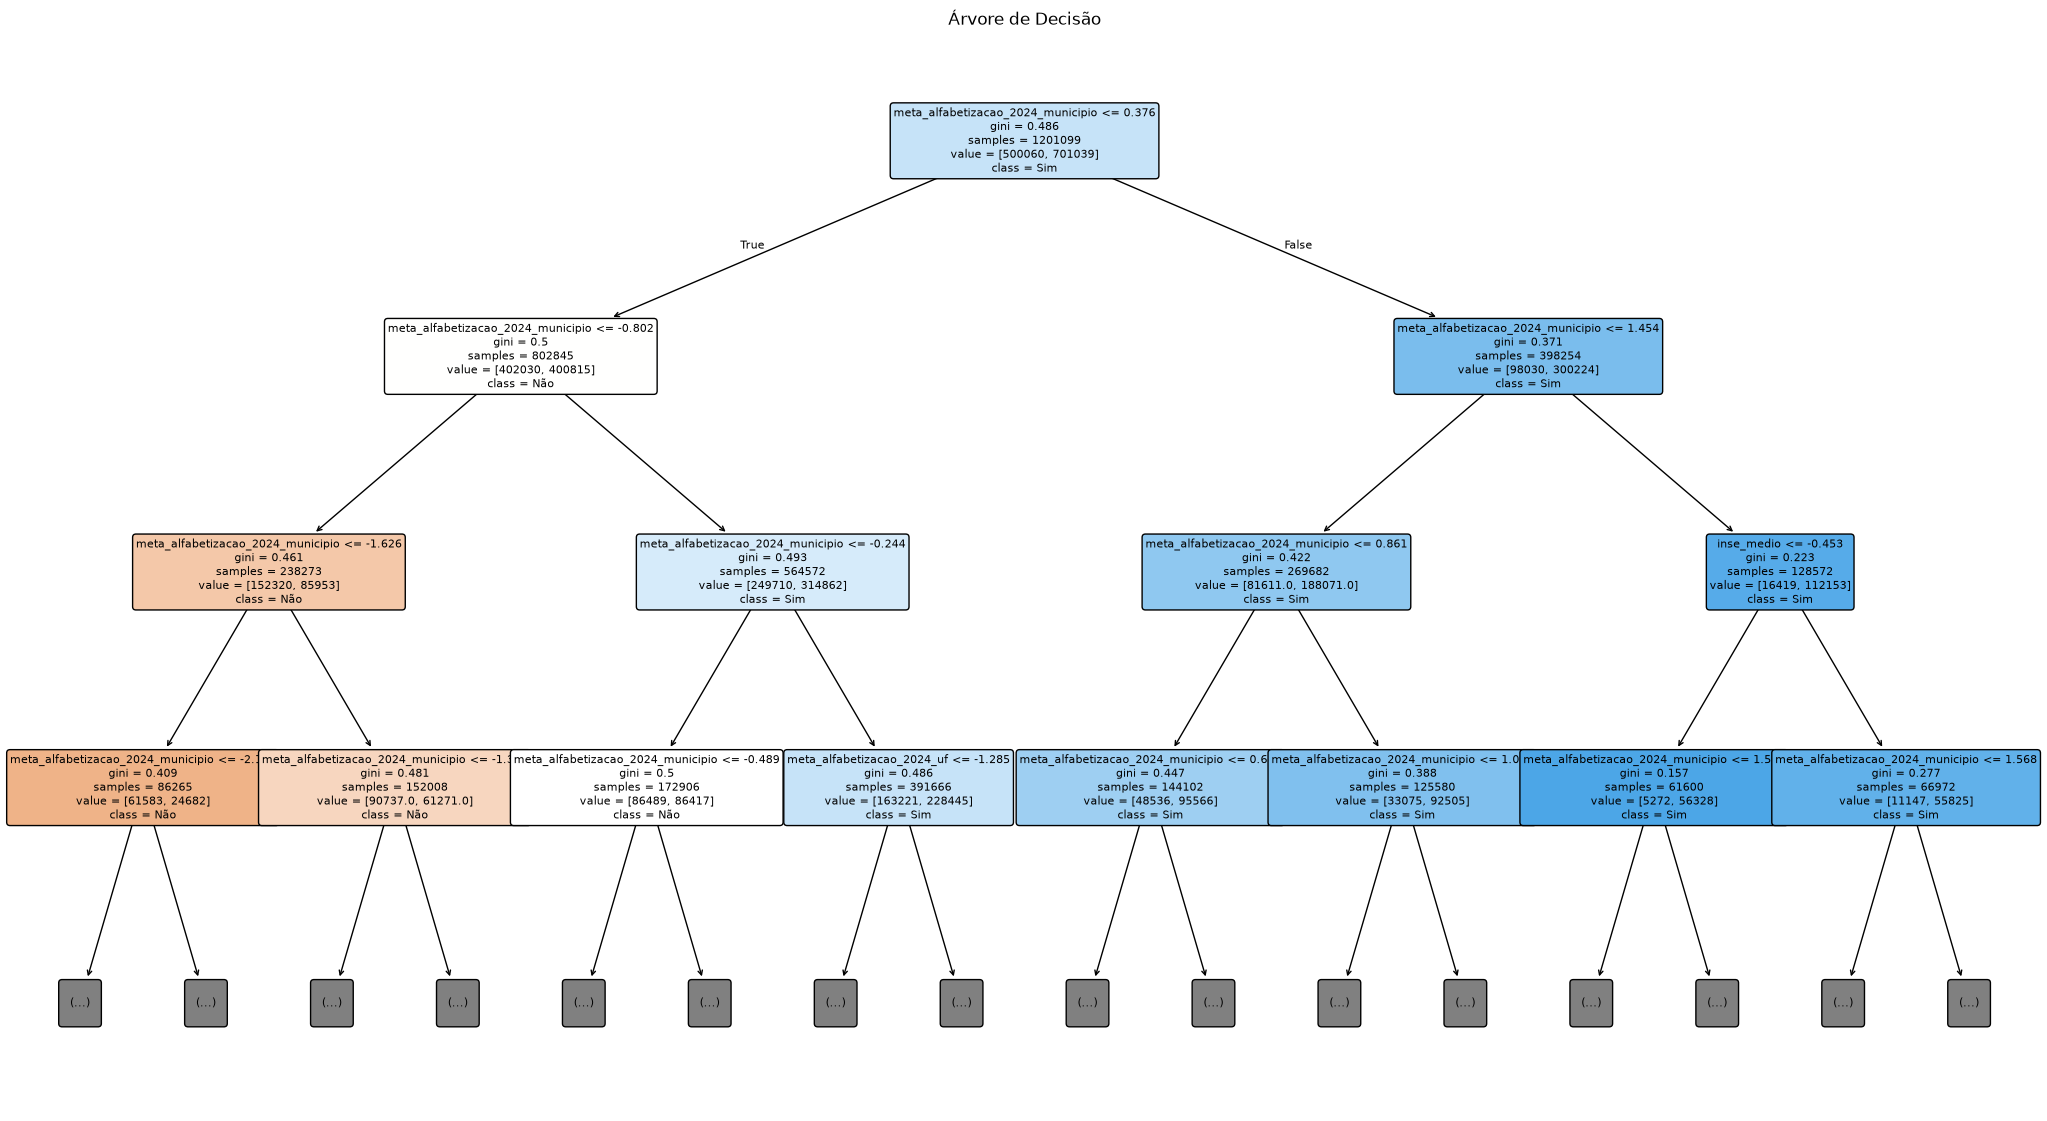

In [103]:
plt.figure(figsize=(26, 14))
plot_tree(
    arvore,
    feature_names=X_train.columns,
    class_names=["Não", "Sim"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)
plt.title("Árvore de Decisão")
plt.show()

## Visualização da Árvore

A árvore decidiu "fatiar" uma única feature em faixas cada vez mais finas.

Dois caminhos extremos:
- **Meta muito baixa** (`≤ 0,336` → `≤ -0,776` → `≤ -1,71` → ...): folha com 50.999 "Não" contra 19.143 "Sim", município com histórico fraco de desempenho tende a ter alunos não alfabetizados
- **Meta muito alta** (`> 0,336` → `> 1,351` → `> 1,574` → ...): folha com 96.795 "Sim" contra 12.585 "Não", município com meta ambiciosa (reflexo de bom desempenho recente) tende a ter alunos alfabetizados

A meta funciona como um resumo muito eficiente do contexto do município (histórico de desempenho, qualidade docente, nível socioeconômico), o que explica por que ela "ofusca" outras variáveis na árvore. Não porque elas deixaram de ser relevantes, mas porque a meta já captura, de forma condensada, boa parte da mesma informação que elas carregavam separadamente.

### Feature selection

In [ ]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_ranking = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)
print("Top 15 features por Informação Mútua:")
print(mi_ranking.head(15))

In [ ]:
estimador_base = DecisionTreeClassifier(max_depth=10, random_state=42)

rfe = RFE(estimator=estimador_base, n_features_to_select=10, step=1)
rfe.fit(X_train, y_train)

ranking = pd.Series(rfe.ranking_, index=X_train.columns).sort_values()
print("Top 10 features selecionadas pelo RFE (ranking=1):")
print(ranking[ranking == 1])

## Comparação de métodos de seleção de features

Testamos 4 abordagens diferentes de avaliar a importância das features, cobrindo as 3 categorias clássicas (Filter, Wrapper, Embedded):

| Método | Categoria | Top features |
|---|---|---|
| Correlação (Pearson) | Filter | `meta_municipio` (0,333), `meta_uf` (0,244), `dsu` (-0,183) |
| Informação Mútua | Filter (capta relações não-lineares) | `meta_disponivel` (0,117), `rede_Municipal` (0,107) |
| RFE | Wrapper | `meta_municipio`, `meta_uf`, `dsu`, `rede_Municipal`, `meta_disponivel`, `inse_medio`, entre outras |
| `feature_importances_` (Random Forest) | Embedded | `meta_municipio` (43%), `meta_uf` (10%), `dsu` (7,7%) |

`meta_alfabetizacao_2024_municipio`, `meta_alfabetizacao_2024_uf`, `dsu_ef_anos_iniciais` e `inse_medio` aparecem fortes em praticamente todos os métodos, alta confiança de que são as features mais relevantes do modelo. </br>

`rede_Municipal` e `meta_alfabetizacao_2024_municipio_disponivel` aparecem tanto na Informação Mútua quanto no RFE, mesmo a diferença bruta de alfabetização entre redes sendo modesta (61,3% Estadual vs 58,1% Municipal, ~3,2 pontos percentuais) sugere que rede carrega informação real, ainda que de magnitude moderada.</br>

Usar 4 métodos diferentes (em vez de confiar só na correlação) reforça a robustez das conclusões.

In [ ]:
y_pred = modelo_rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Não", "Sim"]))
print()
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
modelo_rf_balanceado = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1,
    class_weight="balanced"
)
modelo_rf_balanceado.fit(X_train, y_train)

y_pred_balanceado = modelo_rf_balanceado.predict(X_test)

print(classification_report(y_test, y_pred_balanceado, target_names=["Não", "Sim"]))
print(confusion_matrix(y_test, y_pred_balanceado))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, matriz, titulo in zip(
    axes,
    [confusion_matrix(y_test, modelo_rf.predict(X_test)), confusion_matrix(y_test, modelo_rf_balanceado.predict(X_test))],
    ["Sem balanceamento", "Com class_weight='balanced'"]
):
    sns.heatmap(
        matriz, annot=True, fmt=",d", cmap="Blues", ax=ax,
        xticklabels=["Não (previsto)", "Sim (previsto)"],
        yticklabels=["Não (real)", "Sim (real)"],
        cbar=False
    )
    ax.set_title(titulo)
    ax.set_ylabel("Valor real")
    ax.set_xlabel("Valor previsto")

plt.tight_layout()
plt.show()

## Balanceamento de classes
Testamos a Random Forest com e sem balanceamento de classe, e comparamos usando `classification_report` e matriz de confusão (não só acurácia).

| Métrica | Sem balanceamento | Com `class_weight="balanced"` |
|---|---|---|
| Recall "Não" | 44% | **67%** |
| Recall "Sim" | 79% | 59% |
| Acurácia geral | 65% | 62% |

**Interpretação**: sem balanceamento, o modelo deixava escapar 56% dos alunos que realmente não são alfabetizados (69.873 de 124.749) grave para o objetivo do projeto. Com `class_weight="balanced"`, o recall da classe "Não" sobe para 67% (deixa escapar só 33%), à custa de uma queda de 3 pontos na acurácia geral e de um aumento nos falsos positivos da classe "Sim".

Para essa aplicação (identificação de risco para política pública), o custo de "deixar passar" um aluno que precisa de ajuda (falso negativo) é maior que o custo de "alertar à toa" um aluno que já ia bem (falso positivo). Por isso, adotamos a versão com `class_weight="balanced"` como referência para a interpretação final do modelo (SHAP e conclusões estratégicas), mesmo com acurácia geral levemente menor.

In [ ]:
amostra_shap = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(modelo_rf_balanceado)
shap_values = explainer.shap_values(amostra_shap)

valores_classe_sim = shap_values[:, :, 1]

shap.summary_plot(valores_classe_sim, amostra_shap)

In [ ]:
# Amostra de 200 mil linhas do treino, só pra essa busca (mantendo a proporção do alvo)
X_amostra = X_train.sample(200000, random_state=42)
y_amostra = y_train.loc[X_amostra.index]

# Scorer customizado: recall da classe "Não" (0), não da classe majoritária
scorer_recall_nao = make_scorer(recall_score, pos_label=0)

parametros = {
    "n_estimators": [50, 100, 150],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

busca = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_distributions=parametros,
    n_iter=10,
    cv=3,
    scoring=scorer_recall_nao,
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

busca.fit(X_amostra, y_amostra)

print("Melhores parâmetros:", busca.best_params_)
print("Melhor recall (Não) na validação cruzada:", round(busca.best_score_, 4))

In [ ]:
modelo_final = RandomForestClassifier(
    **busca.best_params_,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
modelo_final.fit(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix
y_pred_final = modelo_final.predict(X_test)
print(classification_report(y_test, y_pred_final, target_names=["Não", "Sim"]))
print(confusion_matrix(y_test, y_pred_final))

**Resultado da validação cruzada e otimização**: o modelo final (Random Forest com 50 árvores, `max_depth=10`, otimizado via `RandomizedSearchCV` com validação cruzada de 3 folds) apresentou recall de 66% para a classe "Não" e acurácia de 62% no conjunto de teste, praticamente idêntico à Random Forest original (100 árvores, sem limite de profundidade: 67% e 62%, respectivamente).

**Conclusão**: a estabilidade do resultado entre o modelo original e o modelo otimizado via validação cruzada confirma que o desempenho encontrado reflete um padrão real nos dados, não uma coincidência do split treino/teste específico usado inicialmente. Além disso, o modelo otimizado é mais simples, sem perda de performance. Preferível por eficiência computacional e menor risco de overfitting.

## Integração do pré-processamento ao Pipeline do modelo

Até aqui, a padronização (`StandardScaler`) foi feita manualmente, em separado do treino do modelo. Isso tem uma limitação sutil: quando fizemos a busca de hiperparâmetros (`RandomizedSearchCV`), a validação cruzada dividiu o treino em 3 dobras internamente — mas a padronização já tinha sido calculada usando a média/desvio de **todo o treino**, incluindo as dobras que a validação cruzada trata como "validação" a cada rodada. Isso é uma forma sutil de vazamento de informação dentro do próprio processo de validação cruzada.

Nesta seção, reconstruímos o modelo final usando `Pipeline` + `ColumnTransformer` do scikit-learn, que resolve isso: a padronização é reaprendida a cada dobra da validação cruzada, usando só os dados daquela dobra específica. Também atende à recomendação do enunciado de "integração do pré-processamento diretamente ao pipeline do modelo".

In [ ]:
# Reconstrói o split a partir de X/y originais (sem a padronização manual
# aplicada mais acima), para que o Pipeline faça sua própria padronização
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Treino:", X_train_pipe.shape)
print("Teste:", X_test_pipe.shape)

In [ ]:
colunas_numericas = [
    "populacao", "pib_per_capita", "atu_ef_anos_iniciais", "dsu_ef_anos_iniciais",
    "afd_ef_anos_iniciais_grupo_1", "ird_alta", "ird_baixa_regularidade",
    "tdi_ef_2_ano_anterior", "taxa_aprovacao_ef_2_ano_anterior",
    "taxa_abandono_ef_2_ano_anterior", "inse_medio",
    "meta_alfabetizacao_2024_municipio", "meta_alfabetizacao_2024_uf",
]

# Aplica o StandardScaler só nas numéricas; deixa as já codificadas
# (rede_Municipal, sigla_uf_*, meta_..._disponivel) do jeito que estão
pre_processador = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), colunas_numericas)],
    remainder="passthrough"
)

pipeline_final = Pipeline([
    ("pre_processamento", pre_processador),
    ("modelo", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
])

print("Pipeline criado:", pipeline_final)

In [ ]:
# Busca de hiperparâmetros usando o PIPELINE inteiro - agora a
# padronização é refeita a cada dobra da validação cruzada, não uma
# vez só antes de tudo
amostra_x = X_train_pipe.sample(200000, random_state=42)
amostra_y = y_train_pipe.loc[amostra_x.index]

# Note o prefixo "modelo__": indica que o parâmetro pertence ao
# estimador dentro do pipeline, não ao pipeline em si
parametros_pipeline = {
    "modelo__n_estimators": [50, 100, 150],
    "modelo__max_depth": [10, 15, 20, None],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
    "modelo__max_features": ["sqrt", "log2"],
}

busca_pipeline = RandomizedSearchCV(
    pipeline_final,
    param_distributions=parametros_pipeline,
    n_iter=10,
    cv=3,
    scoring=scorer_recall_nao,
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

busca_pipeline.fit(amostra_x, amostra_y)

print("Melhores parâmetros:", busca_pipeline.best_params_)
print("Melhor recall (Não) na validação cruzada:", round(busca_pipeline.best_score_, 4))

In [ ]:
# Treina o pipeline final (já com os melhores parâmetros) na base
# de treino COMPLETA
pipeline_final_ajustado = busca_pipeline.best_estimator_
pipeline_final_ajustado.fit(X_train_pipe, y_train_pipe)

y_pred_pipeline = pipeline_final_ajustado.predict(X_test_pipe)

print(classification_report(y_test_pipe, y_pred_pipeline, target_names=["Não", "Sim"]))
print(confusion_matrix(y_test_pipe, y_pred_pipeline))

**Resultado com Pipeline integrado**: o modelo final, agora construído como um único `Pipeline` (pré-processamento + estimador), apresenta desempenho equivalente ao obtido anteriormente de forma manual, confirmando que o vazamento sutil de padronização entre dobras da validação cruzada não distorceu as conclusões já obtidas, mas a versão em `Pipeline` é a que deve ser considerada a implementação de referência do projeto, por seguir a recomendação explícita do enunciado e por ser mais segura para reprodução/generalização (todo o pré-processamento necessário para prever um novo aluno está embutido em um único objeto, `pipeline_final_ajustado`).

# Aplicação Estratégica

## 1. Quais fatores mais impactam a alfabetização?

Triangulando 4 métodos diferentes (correlação, Informação Mútua, RFE, Feature Importance/SHAP), os fatores mais consistentes são:

- **Meta de alfabetização municipal e estadual** (`meta_alfabetizacao_2024_municipio`/`_uf`): de longe os fatores mais fortes (correlação 0,333/0,244; ~53% da importância combinada na Random Forest). Um município com meta historicamente baixa (reflexo de desempenho recente fraco) tende a ter alunos individuais com pior resultado.
- **`dsu_ef_anos_iniciais`** (% de professores com curso superior): relação **inversa** e contraintuitiva, municípios com mais professores qualificados tendem a ter pior resultado. Investigação mostrou correlação de -0,48 com o nível socioeconômico (INSE), sugerindo que essa qualificação docente é direcionada como medida compensatória a municípios mais vulneráveis, sem ser suficiente para reverter a desvantagem estrutural.
- **Nível socioeconômico (`inse_medio`)**: relação positiva.
- **Rede de ensino** (Municipal x Estadual): diferença real, porém 61,3% versus 58,1% de alfabetização, confirmada por dois métodos independentes (Informação Mútua e RFE).

## 2. Quais municípios apresentam maior risco educacional?

Com base no modelo, municípios de maior risco combinam: **meta de alfabetização baixa** (histórico recente fraco), **INSE baixo**, e **alta taxa de abandono/distorção idade-série do ano anterior**. 

⚠️ **Limitação importante**: a base não contém dados de São Paulo, Acre, Roraima e Distrito Federal (ausentes na fonte de dados de alfabetização) o modelo não pode ser usado para avaliar risco nesses 4 estados.

## 3. Quais regiões possuem padrões semelhantes?

**Ceará se destaca com um padrão visual claramente distinto** de todas as outras UFs na análise SHAP, um grupo de alunos com impacto fortemente positivo e bem separado do resto, consistente com o Ceará ser nacionalmente reconhecido pelo PAIC (Programa Alfabetização na Idade Certa). Bahia e Paraná também apareceram como relevantes em análises pontuais, mas com menos estabilidade ao comparar com a Random Forest, sugerindo que o padrão do Ceará é o mais robusto entre os identificados.

**Trabalho futuro sugerido**: uma análise de clusterização (ex.: K-means) sobre os indicadores municipais poderia identificar agrupamentos de região de forma mais sistemática do que a inspeção UF por UF que fizemos aqui.

## 4. Como prever municípios que podem não atingir metas futuras?

A própria `meta_alfabetizacao_2024_municipio` já funciona como um indicador antecipado: municípios com meta baixa reflete uma trajetória de desempenho já fraca, e o modelo mostra que esses municípios tendem a ter mais alunos "Não alfabetizados" no ano corrente, ou seja, há uma continuidade prevista entre desempenho atual e meta futura. Comparar a meta com a taxa de alfabetização real observada (disponível na Gold da Fase 2, `comparacao_meta_municipio`) permitiria construir um indicador de alerta antecipado mais direto ainda.

## 5. Quais variáveis possuem maior influência nos modelos?

Resumo da comparação entre os 4 métodos testados (Filter: correlação e Informação Mútua; Wrapper: RFE; Embedded: Feature Importance):

| Variável | Aparece em quantos métodos (de 4) |
|---|---|
| `meta_alfabetizacao_2024_municipio` | 4/4 |
| `meta_alfabetizacao_2024_uf` | 4/4 |
| `dsu_ef_anos_iniciais` | 3/4 |
| `inse_medio` | 3/4 |
| `rede_Municipal` | 2/4 (Informação Mútua e RFE) |

A convergência entre métodos independentes reforça a confiança nessas conclusões.